# Lab Assignment Five: Wide and Deep Network Architectures

In [111]:
import pandas as pd

In [112]:
# Read the data
df = pd.read_csv('nyc-rolling-sales.csv')
df.head()

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00


In [113]:
print(df.shape)

(84548, 22)


In [114]:
# Clean column names: strip spaces and convert to lowercase
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
# Preview cleaned column names
print(df.columns)

Index(['unnamed:_0', 'borough', 'neighborhood', 'building_class_category',
       'tax_class_at_present', 'block', 'lot', 'ease-ment',
       'building_class_at_present', 'address', 'apartment_number', 'zip_code',
       'residential_units', 'commercial_units', 'total_units',
       'land_square_feet', 'gross_square_feet', 'year_built',
       'tax_class_at_time_of_sale', 'building_class_at_time_of_sale',
       'sale_price', 'sale_date'],
      dtype='object')


In [115]:
# Drop duplicate rows
df = df.drop_duplicates()
print(f"Remaining rows after dropping duplicates: {df.shape[0]}")

Remaining rows after dropping duplicates: 84548


No duplicates

In [116]:
# Check for missing values
missing_counts = df.isnull().sum()
print("Missing values per column:\n", missing_counts)
# Drop rows with any missing values
df = df.dropna()
print(f"Remaining rows after dropping NAs: {df.shape[0]}")

Missing values per column:
 unnamed:_0                        0
borough                           0
neighborhood                      0
building_class_category           0
tax_class_at_present              0
block                             0
lot                               0
ease-ment                         0
building_class_at_present         0
address                           0
apartment_number                  0
zip_code                          0
residential_units                 0
commercial_units                  0
total_units                       0
land_square_feet                  0
gross_square_feet                 0
year_built                        0
tax_class_at_time_of_sale         0
building_class_at_time_of_sale    0
sale_price                        0
sale_date                         0
dtype: int64
Remaining rows after dropping NAs: 84548


No missing values

In [117]:
# Drop columns that aren't useful for modeling
irrelevant_cols = [
    'ease-ment', 'address', 'apartment_number', 'sale_date', 
    'block', 'lot', 'zip_code'
]
df = df.drop(columns=irrelevant_cols, errors='ignore')

Drop irrelevant columns

In [118]:
# Clean and convert 'land_square_feet' and 'gross_square_feet' to numeric
for col in ['land_square_feet', 'gross_square_feet']:
    df[col] = pd.to_numeric(df[col].str.replace(',', '').replace(' ', ''), errors='coerce')

# Drop rows where these important values are missing or zero
df = df.dropna(subset=['land_square_feet', 'gross_square_feet'])
df = df[(df['land_square_feet'] > 0) & (df['gross_square_feet'] > 0)]

In [119]:
# Convert sale_price to numeric
df['sale_price'] = pd.to_numeric(df['sale_price'].str.replace(',', '').replace(' ', ''), errors='coerce')

# Drop rows with missing or 0 sale price
df = df.dropna(subset=['sale_price'])
df = df[df['sale_price'] > 0]

Conver numeric like strings to integers

In [120]:
# Building age
df['building_age'] = 2023 - df['year_built']
df['building_age'] = df['building_age'].replace({2023: None})  # If year_built was 0

# Price per square foot
df['price_per_sqft'] = df['sale_price'] / df['gross_square_feet']

# Remove entries with implausible building age or price/sqft
df = df[(df['building_age'] > 0) & (df['price_per_sqft'] < 10000)]

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29308 entries, 0 to 84547
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   unnamed:_0                      29308 non-null  int64  
 1   borough                         29308 non-null  int64  
 2   neighborhood                    29308 non-null  object 
 3   building_class_category         29308 non-null  object 
 4   tax_class_at_present            29308 non-null  object 
 5   building_class_at_present       29308 non-null  object 
 6   residential_units               29308 non-null  int64  
 7   commercial_units                29308 non-null  int64  
 8   total_units                     29308 non-null  int64  
 9   land_square_feet                29308 non-null  float64
 10  gross_square_feet               29308 non-null  float64
 11  year_built                      29308 non-null  int64  
 12  tax_class_at_time_of_sale       29308

In [122]:
from sklearn.preprocessing import LabelEncoder

In [123]:
# Convert 'building_age' to numeric (replace any non-numeric with NaN)
df['building_age'] = pd.to_numeric(df['building_age'], errors='coerce')

categorical_columns = [
    'neighborhood', 
    'building_class_category', 
    'tax_class_at_present', 
    'building_class_at_present', 
    'building_class_at_time_of_sale'
]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))


In [124]:
# Check the cleaned dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29308 entries, 0 to 84547
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   unnamed:_0                      29308 non-null  int64  
 1   borough                         29308 non-null  int64  
 2   neighborhood                    29308 non-null  int64  
 3   building_class_category         29308 non-null  int64  
 4   tax_class_at_present            29308 non-null  int64  
 5   building_class_at_present       29308 non-null  int64  
 6   residential_units               29308 non-null  int64  
 7   commercial_units                29308 non-null  int64  
 8   total_units                     29308 non-null  int64  
 9   land_square_feet                29308 non-null  float64
 10  gross_square_feet               29308 non-null  float64
 11  year_built                      29308 non-null  int64  
 12  tax_class_at_time_of_sale       29308

In [125]:
df.head()

,unnamed:_0,borough,neighborhood,building_class_category,tax_class_at_present,building_class_at_present,residential_units,commercial_units,total_units,land_square_feet,gross_square_feet,year_built,tax_class_at_time_of_sale,building_class_at_time_of_sale,sale_price,building_age,price_per_sqft
0,4,1,1,5,2,15,5,0,5,1633.0,6440.0,1900,2,15,6625000.0,123,1028.726708
3,7,1,1,5,3,17,10,0,10,2272.0,6794.0,1913,2,17,3936272.0,110,579.374742
4,8,1,1,5,2,15,6,0,6,2369.0,4615.0,1900,2,15,8000000.0,123,1733.477790
6,10,1,1,5,3,17,8,0,8,1750.0,4226.0,1920,2,17,3192840.0,103,755.522953
9,13,1,1,6,1,30,24,0,24,4489.0,18523.0,1920,2,30,16232000.0,103,876.315932


The final dataset contains 29,308 entries and 17 columns, with both categorical and numerical features. Key transformations include:

One-hot encoding of categorical variables like neighborhood, building_class_category, tax_class_at_present, building_class_at_present, and building_class_at_time_of_sale, creating binary columns for each category.

Conversion of the building_age column from a string to an integer, representing the building's age.

The target variable for modeling is sale_price, a continuous variable representing the sale price of the property.

Several columns, such as unnamed:_0, were removed as they were irrelevant.

The final dataset is now prepared for use in classification or regression tasks, with clean and numeric representations of the original features.

In [126]:
# Creating the cross-product features

# borough x neighborhood
df['borough_neighborhood'] = df['borough'].astype(str) + '_' + df['neighborhood'].astype(str)
# building_class_category x building_class_at_present
df['building_class_cat_present'] = df['building_class_category'].astype(str) + '_' + df['building_class_at_present'].astype(str)
# tax_class_at_present x tax_class_at_time_of_sale
df['tax_class_interaction'] = df['tax_class_at_present'].astype(str) + '_' + df['tax_class_at_time_of_sale'].astype(str)
# building_class_at_time_of_sale x building_age
df['building_class_age_interaction'] = df['building_class_at_time_of_sale'].astype(str) + '_' + df['building_age'].astype(str)

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29308 entries, 0 to 84547
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   unnamed:_0                      29308 non-null  int64  
 1   borough                         29308 non-null  int64  
 2   neighborhood                    29308 non-null  int64  
 3   building_class_category         29308 non-null  int64  
 4   tax_class_at_present            29308 non-null  int64  
 5   building_class_at_present       29308 non-null  int64  
 6   residential_units               29308 non-null  int64  
 7   commercial_units                29308 non-null  int64  
 8   total_units                     29308 non-null  int64  
 9   land_square_feet                29308 non-null  float64
 10  gross_square_feet               29308 non-null  float64
 11  year_built                      29308 non-null  int64  
 12  tax_class_at_time_of_sale       29308

In [128]:
# Checking the new dataframe with the cross-product features
df.head()

,unnamed:_0,borough,neighborhood,building_class_category,tax_class_at_present,building_class_at_present,residential_units,commercial_units,total_units,land_square_feet,...,year_built,tax_class_at_time_of_sale,building_class_at_time_of_sale,sale_price,building_age,price_per_sqft,borough_neighborhood,building_class_cat_present,tax_class_interaction,building_class_age_interaction
0,4,1,1,5,2,15,5,0,5,1633.0,...,1900,2,15,6625000.0,123,1028.726708,1_1,5_15,2_2,15_123
3,7,1,1,5,3,17,10,0,10,2272.0,...,1913,2,17,3936272.0,110,579.374742,1_1,5_17,3_2,17_110
4,8,1,1,5,2,15,6,0,6,2369.0,...,1900,2,15,8000000.0,123,1733.477790,1_1,5_15,2_2,15_123
6,10,1,1,5,3,17,8,0,8,1750.0,...,1920,2,17,3192840.0,103,755.522953,1_1,5_17,3_2,17_103
9,13,1,1,6,1,30,24,0,24,4489.0,...,1920,2,30,16232000.0,103,876.315932,1_1,6_30,1_2,30_103


borough_neighborhood: Combines the borough and neighborhood columns, which represent location-based information, into a new interaction feature.

building_class_cat_present: Combines the building_class_category and building_class_at_present to capture the interaction between the type of building and its current classification.

tax_class_interaction: Combines tax_class_at_present and tax_class_at_time_of_sale to track changes in the tax classification between the current time and the sale time.

building_class_age_interaction: Combines building_class_at_time_of_sale and building_age to see how the building's class and age relate.

In [129]:
# Convert cross-product features to numerical using LabelEncoder
le = LabelEncoder()
df['borough_neighborhood'] = le.fit_transform(df['borough_neighborhood'])
df['building_class_cat_present'] = le.fit_transform(df['building_class_cat_present']) 
df['tax_class_interaction'] = le.fit_transform(df['tax_class_interaction'])
df['building_class_age_interaction'] = le.fit_transform(df['building_class_age_interaction'])

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29308 entries, 0 to 84547
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   unnamed:_0                      29308 non-null  int64  
 1   borough                         29308 non-null  int64  
 2   neighborhood                    29308 non-null  int64  
 3   building_class_category         29308 non-null  int64  
 4   tax_class_at_present            29308 non-null  int64  
 5   building_class_at_present       29308 non-null  int64  
 6   residential_units               29308 non-null  int64  
 7   commercial_units                29308 non-null  int64  
 8   total_units                     29308 non-null  int64  
 9   land_square_feet                29308 non-null  float64
 10  gross_square_feet               29308 non-null  float64
 11  year_built                      29308 non-null  int64  
 12  tax_class_at_time_of_sale       29308

In [131]:
df.head()

,unnamed:_0,borough,neighborhood,building_class_category,tax_class_at_present,building_class_at_present,residential_units,commercial_units,total_units,land_square_feet,...,year_built,tax_class_at_time_of_sale,building_class_at_time_of_sale,sale_price,building_age,price_per_sqft,borough_neighborhood,building_class_cat_present,tax_class_interaction,building_class_age_interaction
0,4,1,1,5,2,15,5,0,5,1633.0,...,1900,2,15,6625000.0,123,1028.726708,0,132,7,616
3,7,1,1,5,3,17,10,0,10,2272.0,...,1913,2,17,3936272.0,110,579.374742,0,134,9,712
4,8,1,1,5,2,15,6,0,6,2369.0,...,1900,2,15,8000000.0,123,1733.477790,0,132,7,616
6,10,1,1,5,3,17,8,0,8,1750.0,...,1920,2,17,3192840.0,103,755.522953,0,134,9,710
9,13,1,1,6,1,30,24,0,24,4489.0,...,1920,2,30,16232000.0,103,876.315932,0,147,4,1058


Since the task involves predicting property prices based on various features, this is a regression problem where we aim to estimate a continuous target variable, namely the sale_price. In such cases, we should avoid using accuracy as it is typically more suitable for classification tasks. Instead, we should focus on metrics that measure the difference between the predicted and actual values, as well as the model's ability to predict the magnitude of these differences.

In [132]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import numpy as np

Using the F1 score for this task would require treating the sale price prediction as a classification problem. By discretizing the continuous sale prices into categories, you can then apply classification metrics like F1 to evaluate the model. This approach can be useful in scenarios where predicting price ranges (rather than exact prices) is more relevant for business purposes.

In [133]:
bins = [0, 500000, 1500000, float('inf')]  # Define price bins
labels = ['Low', 'Medium', 'High']  # Labels for the categories
df['price_category'] = pd.cut(df['sale_price'], bins=bins, labels=labels, right=False)

In [134]:
X = df.drop(columns=['sale_price', 'price_category'])
y = df['price_category']

In [135]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# List to store F1 scores for each fold
f1_scores = []

# Stratified K-Fold Cross-Validation
for train_index, test_index in skf.split(X, y):
    # Split data into train and test sets
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Train a RandomForest Classifier
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    
    # Predict and calculate F1 score
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')  # Weighted average to handle class imbalance
    f1_scores.append(f1)

# Calculate the average F1 score
average_f1 = np.mean(f1_scores)
print(f"Average F1 Score from 10-Fold Cross-Validation: {average_f1}")

Average F1 Score from 10-Fold Cross-Validation: 0.9591540289448016


Stratified 10-Fold Cross-Validation is the best method for splitting the data into training and testing sets for this task. It ensures a balanced and representative evaluation of the model’s performance, particularly given the class imbalance in property prices. It is both computationally feasible and appropriate for the business context of categorizing properties into price ranges.

In [141]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical


In [140]:

# 1. Bin sale_price into categories
# You can adjust the bins as needed
bins = [0, 500000, 1000000, np.inf]
labels = ['Low', 'Medium', 'High']
df['price_label'] = pd.cut(df['sale_price'], bins=bins, labels=labels)

# 2. Define features and target
X = df.drop(columns=['sale_price', 'price_label'])  # drop target and raw price
y = df['price_label']

# 3. Feature groups
wide_features = ['borough', 'neighborhood', 'building_class_category', 
                 'tax_class_at_present', 'building_class_at_present']
deep_features = ['residential_units', 'commercial_units', 'total_units',
                 'land_square_feet', 'gross_square_feet', 'year_built',
                 'tax_class_at_time_of_sale', 'building_class_at_time_of_sale',
                 'building_age', 'price_per_sqft']

# 4. One-hot encode wide features
X_wide = pd.get_dummies(X[wide_features])

# 5. Deep features (scale numeric)
X_deep = X[deep_features].astype(float)
scaler = StandardScaler()
X_deep = scaler.fit_transform(X_deep)

# 6. Encode labels and convert to categorical
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(y)
y_cat = to_categorical(y_int)

# 7. Train-test split
Xw_train, Xw_val, Xd_train, Xd_val, y_train, y_val = train_test_split(
    X_wide, X_deep, y_cat, test_size=0.2, random_state=42, stratify=y_int
)

# Ready to model!
print(f"Xw_train shape: {Xw_train.shape}")
print(f"Xd_train shape: {Xd_train.shape}")
print(f"y_train shape: {y_train.shape}")


Xw_train shape: (23446, 5)
Xd_train shape: (23446, 10)
y_train shape: (23446, 3)


In [142]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

Epoch 1/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - accuracy: 0.4351 - loss: 25.3250 - val_accuracy: 0.5595 - val_loss: 3.5020
Epoch 2/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step - accuracy: 0.6068 - loss: 2.0981 - val_accuracy: 0.7213 - val_loss: 0.6221
Epoch 3/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - accuracy: 0.7314 - loss: 0.6127 - val_accuracy: 0.7497 - val_loss: 0.5727
Epoch 4/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - accuracy: 0.7569 - loss: 0.5637 - val_accuracy: 0.7668 - val_loss: 0.5423
Epoch 5/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step - accuracy: 0.7736 - loss: 0.5303 - val_accuracy: 0.7849 - val_loss: 0.5042
Epoch 6/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step - accuracy: 0.7916 - loss: 0.5047 - val_accuracy: 0.7955 - val_loss: 0.4771
Epoch 7/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step - accuracy: 0.8003 - loss: 0.4762 - val_accuracy: 0.8100 - val_loss: 0.4473
Epoch 8/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step - accuracy: 0.8211 - loss: 0.4348 -

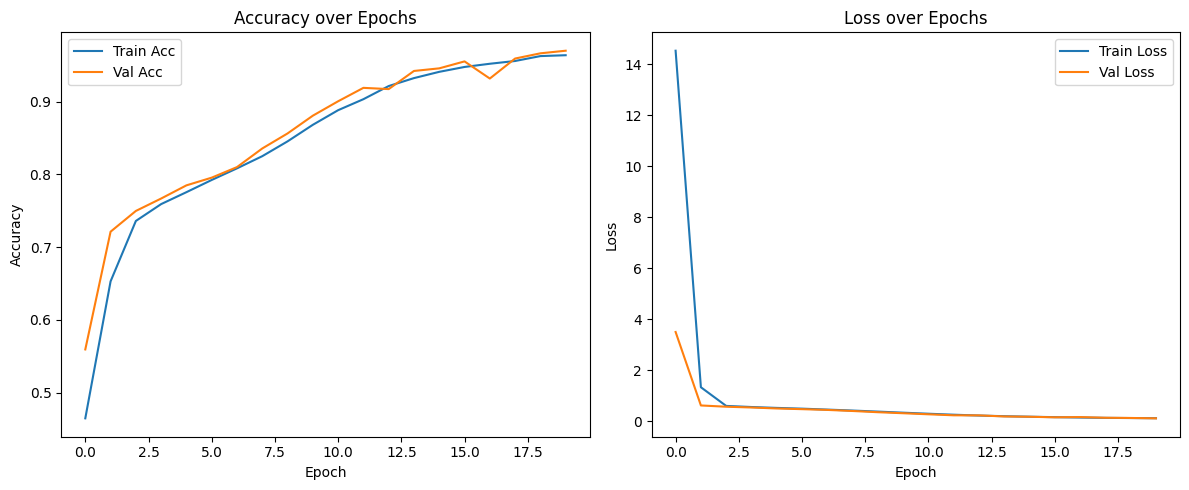

In [143]:
# 1. Wide input
input_wide = Input(shape=(Xw_train.shape[1],), name='wide_input')

# 2. Deep input with hidden layers
input_deep = Input(shape=(Xd_train.shape[1],), name='deep_input')
deep = Dense(64, activation='relu')(input_deep)
deep = Dense(32, activation='relu')(deep)

# 3. Combine wide and deep
combined = Concatenate()([input_wide, deep])
output = Dense(3, activation='softmax')(combined)

# 4. Model setup
model = Model(inputs=[input_wide, input_deep], outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 5. Train the model
history = model.fit(
    [Xw_train, Xd_train], y_train,
    validation_data=([Xw_val, Xd_val], y_val),
    epochs=20,
    batch_size=64
)

# 6. Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [144]:
# Convert categorical y back to label form for stratified splitting
y_labels = y_cat.argmax(axis=1)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def build_model(layers_config):
    input_wide = Input(shape=(X_wide.shape[1],))
    input_deep = Input(shape=(X_deep.shape[1],))
    
    deep = input_deep
    for units in layers_config:
        deep = Dense(units, activation='relu')(deep)
    
    combined = Concatenate()([input_wide, deep])
    output = Dense(3, activation='softmax')(combined)
    
    model = Model(inputs=[input_wide, input_deep], outputs=output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [145]:
def evaluate_model(layers_config, X_wide, X_deep, y_cat, y_labels):
    f1_scores = []

    for train_idx, val_idx in kf.split(X_wide, y_labels):
        Xw_train, Xw_val = X_wide[train_idx], X_wide[val_idx]
        Xd_train, Xd_val = X_deep[train_idx], X_deep[val_idx]
        y_train, y_val = y_cat[train_idx], y_cat[val_idx]

        model = build_model(layers_config)
        model.fit([Xw_train, Xd_train], y_train, epochs=10, batch_size=64, verbose=0)
        
        preds = model.predict([Xw_val, Xd_val])
        y_pred = preds.argmax(axis=1)
        y_true = y_val.argmax(axis=1)

        f1 = f1_score(y_true, y_pred, average='macro')
        f1_scores.append(f1)

    return np.mean(f1_scores), np.std(f1_scores)


In [146]:
Xw_array = X_wide.values
Xd_array = X_deep
y_array = y_cat

# Model 1: 64 → 32 (baseline)
f1_1, std_1 = evaluate_model([64, 32], Xw_array, Xd_array, y_array, y_labels)
print(f'Model 1 (2 layers): F1 = {f1_1:.4f} ± {std_1:.4f}')

# Model 2: 64 (shallow)
f1_2, std_2 = evaluate_model([64], Xw_array, Xd_array, y_array, y_labels)
print(f'Model 2 (1 layer): F1 = {f1_2:.4f} ± {std_2:.4f}')

# Model 3: 128 → 64 → 32 (deeper)
f1_3, std_3 = evaluate_model([128, 64, 32], Xw_array, Xd_array, y_array, y_labels)
print(f'Model 3 (3 layers): F1 = {f1_3:.4f} ± {std_3:.4f}')


184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 422us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 395us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 408us/step
Model 1 (2 layers): F1 = 0.9227 ± 0.0188
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 428us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step
Model 2 (1 layer): F1 = 0.8104 ± 0.0072
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step
Model 3 (3 layers): F1 = 0.9506 ± 0.0181


In [147]:
def build_mlp_model(layers_config):
    input_deep = Input(shape=(X_deep.shape[1],))
    x = input_deep
    for units in layers_config:
        x = Dense(units, activation='relu')(x)
    output = Dense(3, activation='softmax')(x)
    
    model = Model(inputs=input_deep, outputs=output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [148]:
from sklearn.metrics import roc_auc_score

In [149]:

def roc_auc_evaluation(model_fn, layers_config, is_wide_and_deep=True):
    aucs = []

    for train_idx, val_idx in kf.split(Xw_array, y_labels):
        if is_wide_and_deep:
            Xw_train, Xw_val = Xw_array[train_idx], Xw_array[val_idx]
            Xd_train, Xd_val = Xd_array[train_idx], Xd_array[val_idx]
            model = model_fn(layers_config)
            model.fit([Xw_train, Xd_train], y_array[train_idx], epochs=10, batch_size=64, verbose=0)
            preds = model.predict([Xw_val, Xd_val])
        else:
            Xd_train, Xd_val = Xd_array[train_idx], Xd_array[val_idx]
            model = model_fn(layers_config)
            model.fit(Xd_train, y_array[train_idx], epochs=10, batch_size=64, verbose=0)
            preds = model.predict(Xd_val)

        auc = roc_auc_score(y_array[val_idx], preds, average='macro', multi_class='ovr')
        aucs.append(auc)

    return np.mean(aucs), np.std(aucs)


In [150]:
# Wide & Deep model
auc_wd, std_wd = roc_auc_evaluation(build_model, [128, 64, 32], is_wide_and_deep=True)
print(f'Wide & Deep Model AUC = {auc_wd:.4f} ± {std_wd:.4f}')

# Deep-only MLP model
auc_mlp, std_mlp = roc_auc_evaluation(build_mlp_model, [128, 64, 32], is_wide_and_deep=False)
print(f'MLP (Deep-only) Model AUC = {auc_mlp:.4f} ± {std_mlp:.4f}')


184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 427us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step
Wide & Deep Model AUC = 0.9936 ± 0.0015
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step
MLP (Deep-only) Model AUC = 0.9966 ± 0.0018
